<a href="https://colab.research.google.com/github/helenxu0624/musa-650-spring2026-Projects/blob/main/EuroStats/eurosat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EuroSAT Project
### Members: Katie Knox, Helen Xu, Ezra Rwakazooba
#### Submission date:  April 5th, 2026

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Change on your computer for connection
import os
%cd "/content/drive/MyDrive/Upenn/Spring_2026/Musa_650/Eruo Stats"
os.getcwd()

/content/drive/.shortcut-targets-by-id/11UQjagLknYv1G9vT3xdOm94p7l9pLSyd/Musa_650/Eruo Stats


'/content/drive/.shortcut-targets-by-id/11UQjagLknYv1G9vT3xdOm94p7l9pLSyd/Musa_650/Eruo Stats'

In [3]:
import zipfile
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from io import BytesIO

### 1. Data Loading, Processing, and Exploration

#### 1.1 Data Preparation

Visit the EuroSAT data description page and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.

In [4]:
ZIP_PATH = r"data/EuroSAT_MS.zip"
EXTRACT_DIR = Path("/content/EuroSAT_MS")

# Extract zip if not already done
if not EXTRACT_DIR.exists():
    print("Extracting zip...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR.parent)
    print("Done.")
else:
    print("Already extracted.")

Already extracted.


In [8]:
# Build list of (file_path, label) pairs from folder names
samples = []
classes = sorted([d.name for d in EXTRACT_DIR.iterdir() if d.is_dir()])
class_to_idx = {cls: i for i, cls in enumerate(classes)}

for cls in classes:
    cls_dir = EXTRACT_DIR / cls
    for img_path in sorted(cls_dir.glob("*.tif")):
        samples.append((img_path, class_to_idx[cls]))

print(f"Classes ({len(classes)}): {classes}")
print(f"Total images: {len(samples)}")

Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000


In [9]:
from collections import Counter

label_counts = Counter(label for _, label in samples)
counts = [label_counts[class_to_idx[cls]] for cls in classes]
total = sum(counts)

for cls, idx in class_to_idx.items():
    class_pcts = np.round(label_counts[idx] / total * 100, 1)
    print(f"  {cls:25s}: {label_counts[idx]:,} images ({class_pcts}%)")

  AnnualCrop               : 3,000 images (11.1%)
  Forest                   : 3,000 images (11.1%)
  HerbaceousVegetation     : 3,000 images (11.1%)
  Highway                  : 2,500 images (9.3%)
  Industrial               : 2,500 images (9.3%)
  Pasture                  : 2,000 images (7.4%)
  PermanentCrop            : 2,500 images (9.3%)
  Residential              : 3,000 images (11.1%)
  River                    : 2,500 images (9.3%)
  SeaLake                  : 3,000 images (11.1%)


<font color='turquoise'>
The dataset has *27000* samples with good class balance.
AnnualCrop, Forest, HerbaceousVegetation, Residential and SeaLake all balance (3,000 samples, ~11.1%), while Highway, Industrial,  PermanentCrop and River   (2500 samples ~9.3%) and Pasture being the least class (2000 samples ~7.4%)
</font>


/tmp/ipykernel_42235/2971806986.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=30, ha="right")


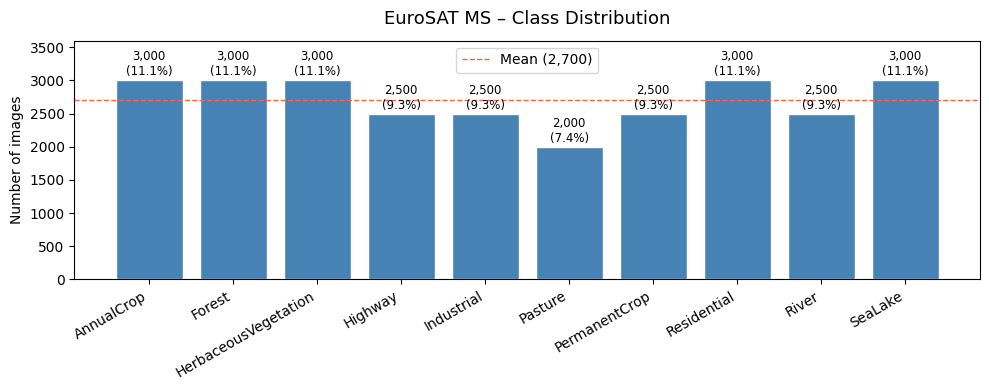

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(classes, counts, color="steelblue", edgecolor="white")

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}\n({count / total:.1%})",
        ha="center",
        va="bottom",
        fontsize=8.5,
    )

mean_count = total // len(classes)
ax.axhline(
    mean_count,
    color="tomato",
    linestyle="--",
    linewidth=1,
    label=f"Mean ({mean_count:,})",
)
ax.set_title("EuroSAT MS – Class Distribution", fontsize=13, pad=12)
ax.set_ylabel("Number of images")
ax.set_ylim(0, max(counts) * 1.2)
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

### Plotting one image from each class in a 2x5 grid.

In [11]:
def load_image(path):
    """Load a multispectral GeoTIFF as a (bands, H, W) numpy array."""
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)  # shape: (13, 64, 64)

# Inspect a single image
img_path, label = samples[0]
img = load_image(img_path)
print(f"Image shape : {img.shape}  (bands, H, W)")
print(f"Label       : {label} ({classes[label]})")
print(f"Value range : {img.min():.0f} – {img.max():.0f}")

Image shape : (13, 64, 64)  (bands, H, W)
Label       : 0 (AnnualCrop)
Value range : 9 – 3490


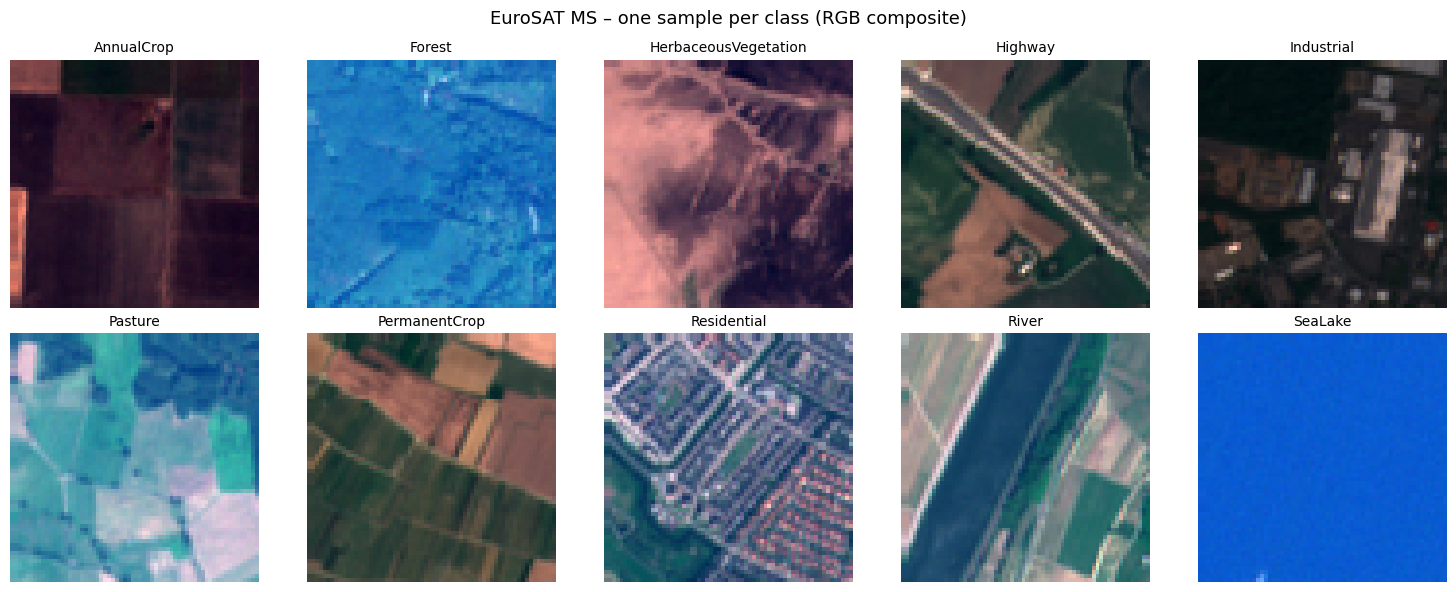

In [34]:
# Sentinel-2 band reference
BAND_NAMES = [
    "B01 (Coastal)", "B02 (Blue)", "B03 (Green)", "B04 (Red)",
    "B05 (Red Edge 1)", "B06 (Red Edge 2)", "B07 (Red Edge 3)",
    "B08 (NIR)", "B08A (Narrow NIR)", "B09 (Water Vapor)",
    "B10 (SWIR Cirrus)", "B11 (SWIR 1)", "B12 (SWIR 2)"
]

# Display one sample per class using RGB (B04, B03, B02)
RED, GREEN, BLUE = 3, 2, 1  # band indices (0-based)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(classes):
    # Grab first sample of this class
    path, _ = next((s, l) for s, l in samples if classes[l] == cls)
    img = load_image(path)

    # Build RGB composite and normalise to [0, 1]
    rgb = np.stack([img[RED], img[GREEN], img[BLUE]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

    axes[i].imshow(rgb)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis("off")

plt.suptitle("EuroSAT MS – one sample per class (RGB composite)", fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 Data Augmentation

Before splitting the data into training and testing sets or doing any preprocessing, apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset.

Indicate the augmentation approach(es) that you used and the total size of the new dataset.

Again, plot three random images and a histogram of the label distribution across the full dataset.

<font color='turquoise'> The data augmentation method we propose are the following;
<br>

<ol>
    <li> Rotating (0-180) degrees
    <li> Zoom
    <li> width shift
    <li> Height shift
</ol>
</font>

In [35]:
from scipy.ndimage import rotate, shift
from scipy.ndimage import zoom as sp_zoom
from tqdm.notebook import tqdm

In [11]:
def load_image(path: Path) -> np.ndarray:
    """Load a .tif or augmented .npy file as a (bands, H, W) float32 array."""
    path = Path(path)
    if path.suffix == ".npy":
        return np.load(path).astype(np.float32)
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)

In [12]:
def augment_rotate(img: np.ndarray, angle: float = 30.0) -> np.ndarray:
    """Rotate image by angle degrees in the spatial (H, W) plane."""
    return rotate(img, angle, axes=(1, 2), reshape=False)


def augment_zoom(img: np.ndarray, factor: float = 1.2) -> np.ndarray:
    """Zoom in by factor and centre-crop back to the original spatial size."""
    _, h, w = img.shape
    zoomed = sp_zoom(img, [1.0, factor, factor])
    _, zh, zw = zoomed.shape
    ch, cw = (zh - h) // 2, (zw - w) // 2
    return zoomed[:, ch : ch + h, cw : cw + w]


def augment_width_shift(img: np.ndarray, shift_px: int = 8) -> np.ndarray:
    """Shift image horizontally by shift_px pixels."""
    return shift(img, [0, 0, shift_px])


def augment_height_shift(img: np.ndarray, shift_px: int = 8) -> np.ndarray:
    """Shift image vertically by shift_px pixels."""
    return shift(img, [0, shift_px, 0])

# for Size I will only use rotate and zoom, as the shifts cause too much blank space around the edges which is not ideal for a small 64x64 image. I will keep the shift functions in case I want to experiment with them later, but I will comment them out of the AUGMENTATIONS dict for now.
AUGMENTATIONS = {
    "rotate": augment_rotate,
    "zoom": augment_zoom,
    #"width_shift": augment_width_shift,
    #"height_shift": augment_height_shift,
}

In [36]:
AUG_DIR = Path("data/augmented")
AUG_DIR.mkdir(parents=True, exist_ok=True)

for cls in classes:
    (AUG_DIR / cls).mkdir(exist_ok=True)

In [23]:
# NO Need TO RUN, Data Stored already
aug_samples = []

for cls in tqdm(classes, desc="Augmenting"):
    idx = class_to_idx[cls]
    cls_paths = [p for p, l in samples if l == idx]

    for path in cls_paths:
        img = load_image(path)
        stem = Path(path).stem

        for aug_name, aug_fn in AUGMENTATIONS.items():
            out_path = AUG_DIR / cls / f"{stem}_{aug_name}.npy"
            if not out_path.exists():
                np.save(out_path, aug_fn(img))
            aug_samples.append((out_path, idx))
print(f"Augmented samples created: {len(aug_samples):,}")

Augmenting:   0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [37]:
AUG_DIR = Path("content/augmented")  # 你的存储路径

aug_samples = []

for cls in classes:
    cls_dir = AUG_DIR / cls

    # 找到该类别下所有 .npy 文件
    for npy_path in sorted(cls_dir.glob("*.npy")):
        aug_samples.append((str(npy_path), class_to_idx[cls]))

print(f"Loaded augmented samples: {len(aug_samples):,}")

Loaded augmented samples: 27,000


In [38]:

all_samples = samples + aug_samples

print(f"Original  : {len(samples):,}")
print(f"Augmented : {len(aug_samples):,}")
print(f"Total     : {len(all_samples):,}")

Original  : 27,000
Augmented : 27,000
Total     : 54,000


In [16]:
all_label_counts = Counter(label for _, label in all_samples)
all_counts = [all_label_counts[class_to_idx[cls]] for cls in classes]
all_total = sum(all_counts)

for cls, idx in class_to_idx.items():
    pct = np.round(all_label_counts[idx] / all_total * 100, 1)
    print(f"  {cls:25s}: {all_label_counts[idx]:,} images ({pct}%)")

  AnnualCrop               : 6,000 images (11.1%)
  Forest                   : 6,000 images (11.1%)
  HerbaceousVegetation     : 6,000 images (11.1%)
  Highway                  : 5,000 images (9.3%)
  Industrial               : 5,000 images (9.3%)
  Pasture                  : 4,000 images (7.4%)
  PermanentCrop            : 5,000 images (9.3%)
  Residential              : 6,000 images (11.1%)
  River                    : 5,000 images (9.3%)
  SeaLake                  : 6,000 images (11.1%)


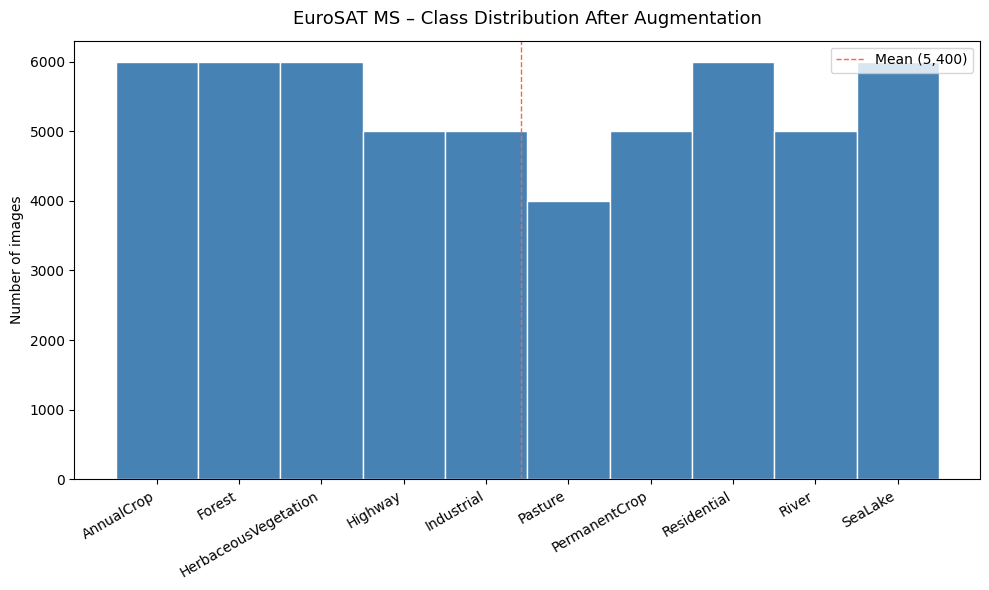

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

label_series = [label for _, label in all_samples]
ax.hist(
    label_series,
    bins=len(classes),
    range=(-0.5, len(classes) - 0.5),
    color="steelblue",
    edgecolor="white",
)

all_mean = all_total // len(classes)
ax.axvline(
    np.mean(label_series),
    color="tomato",
    linestyle="--",
    linewidth=1,
    label=f"Mean ({all_mean:,})",
)
ax.set_title("EuroSAT MS \u2013 Class Distribution After Augmentation", fontsize=13, pad=12)
ax.set_ylabel("Number of images")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

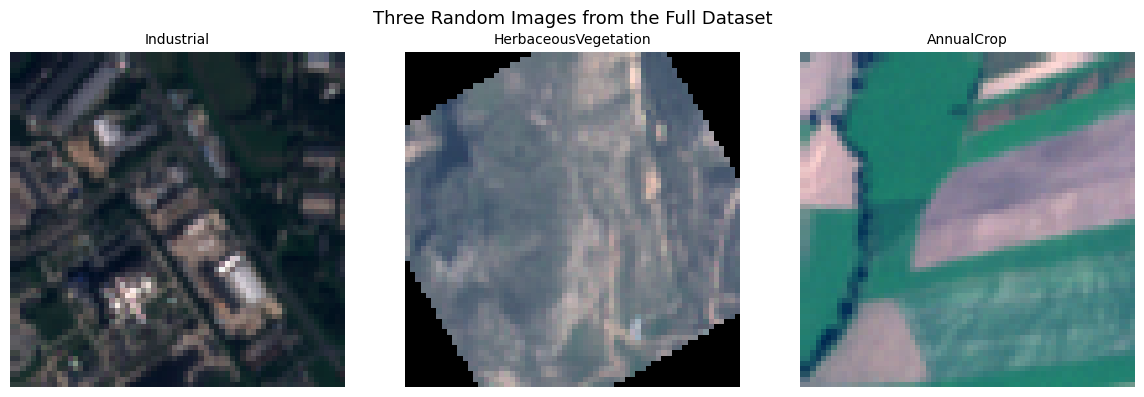

In [18]:
import random

def load_any_image(path):
    """
    Load either:
    - original .tif image -> return RGB composite from MS bands
    - augmented .npy image -> load directly
    Returns image in (H, W, 3), normalized to [0, 1]
    """
    path = Path(path)

    if path.suffix == ".npy":
        img = np.load(path)

        # if saved as (bands, H, W), convert to RGB
        if img.ndim == 3 and img.shape[0] == 13:
            rgb = np.stack([img[3], img[2], img[1]], axis=-1)
        # if already saved as (H, W, 3)
        elif img.ndim == 3 and img.shape[-1] == 3:
            rgb = img
        else:
            raise ValueError(f"Unexpected .npy shape: {img.shape}")

    else:
        # original multispectral tif
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)   # (13, H, W)
        rgb = np.stack([img[3], img[2], img[1]], axis=-1)

    # normalize for display
    rgb = rgb.astype(np.float32)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
    return rgb


# plot three random images from the full dataset
random_samples = random.sample(all_samples, 3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (img_path, label) in zip(axes, random_samples):
    rgb = load_any_image(img_path)
    ax.imshow(rgb)
    ax.set_title(classes[label], fontsize=10)
    ax.axis("off")

plt.suptitle("Three Random Images from the Full Dataset", fontsize=13)
plt.tight_layout()
plt.show()

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.

In [19]:
import dask
from dask import delayed
from dask.diagnostics import ProgressBar
from sklearn.model_selection import train_test_split

In [31]:
# NO NEED TO RUN
# Too Many Samples, ignore the following three chunk, only use the need samples

'''
@delayed
def load_flat(path: Path) -> np.ndarray:
    """Load one image and flatten to a 1-D (bands × H × W) float32 array."""
    return load_image(path).flatten()


y = np.array([lbl for _, lbl in all_samples], dtype=np.int32)
lazy_rows = [load_flat(path) for path, _ in all_samples]

with ProgressBar():
    rows = dask.compute(*lazy_rows, scheduler="threads")

X = np.stack(rows).astype(np.float32)

print(f"X shape : {X.shape}  (n={X.shape[0]:,} samples, p={X.shape[1]:,} pixels)")
print(f"y shape : {y.shape}")
print(f"RAM     : {X.nbytes / 1e9:.1f} GB")

'''

KeyboardInterrupt: 

In [ ]:
# NO NEED TO RUN
'''
indices = np.arange(len(all_samples))

idx_train, idx_test, y_train, y_test = train_test_split(
    indices, y, test_size=0.4, stratify=y, random_state=42
)

X_train, X_test = X[idx_train], X[idx_test]

print(f"Train : X={X_train.shape},  y={y_train.shape}")
print(f"Test  : X={X_test.shape},   y={y_test.shape}")
'''

Train : X=(32400, 53248),  y=(32400,)
Test  : X=(21600, 53248),   y=(21600,)


In [ ]:
# NO NEED TO RUN
'''
# Reshape to (n, 13, 64, 64) to isolate visible RGB bands
n = X.shape[0]
X_cube = X.reshape(n, 13, 64, 64)

# Luminance-weighted grayscale from B04 (Red), B03 (Green), B02 (Blue)
R = X_cube[:, 3].reshape(n, -1)
G = X_cube[:, 2].reshape(n, -1)
B = X_cube[:, 1].reshape(n, -1)

X_gray = (0.2989 * R + 0.5870 * G + 0.1140 * B).astype(np.float32)

X_gray_train = X_gray[idx_train]
X_gray_test = X_gray[idx_test]

print(f"X_gray       : {X_gray.shape}  ({X_gray.nbytes / 1e9:.1f} GB)")
print(f"X_gray_train : {X_gray_train.shape}")
print(f"X_gray_test  : {X_gray_test.shape}")
'''

X_gray       : (54000, 4096)  (0.9 GB)
X_gray_train : (32400, 4096)
X_gray_test  : (21600, 4096)


In [20]:
# Extract Forest/Residential/Industrial for flattern, select RGB first and then flatterned
target_classes = ["Forest", "Residential", "Industrial"]
target_idx = [class_to_idx[c] for c in target_classes]

subset_samples = [(path, lbl) for path, lbl in all_samples if lbl in target_idx]

print("Selected classes:", target_classes)
print("Class indices:", target_idx)
print("Subset size:", len(subset_samples))

Selected classes: ['Forest', 'Residential', 'Industrial']
Class indices: [1, 7, 4]
Subset size: 17000


In [21]:
# check path
print(samples[0][0])
print(aug_samples[0][0])

print(Path(samples[0][0]).exists())
print(Path(aug_samples[0][0]).exists())

/content/EuroSAT_MS/AnnualCrop/AnnualCrop_1.tif
content/augmented/AnnualCrop/AnnualCrop_1000_rotate.npy
True
True


In [40]:
def load_ms_array(path):
    path = Path(path)

    if path.suffix == ".npy":
        img = np.load(path).astype(np.float32)
        if img.ndim == 3 and img.shape[0] == 13:
            return img
        else:
            raise ValueError(f"Unexpected npy shape for MS data: {img.shape}")

    else:
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)   # (13, H, W)
        return img

In [23]:
# Gray scale
from tqdm import tqdm

# Gray scale
def ms_to_rgb(ms_img):
    # Sentinel-2: B04, B03, B02 -> R, G, B
    return np.stack([ms_img[3], ms_img[2], ms_img[1]], axis=-1)  # (H, W, 3)

def rgb_to_gray(rgb_img):
    return (
        0.2989 * rgb_img[..., 0] +
        0.5870 * rgb_img[..., 1] +
        0.1140 * rgb_img[..., 2]
    ).astype(np.float32)

X_gray = []
y_subset = []

for path, lbl in tqdm(subset_samples, desc="Converting MS to grayscale"):
    ms = load_ms_array(path)
    rgb = ms_to_rgb(ms)
    gray = rgb_to_gray(rgb)

    X_gray.append(gray)
    y_subset.append(lbl)

X_gray = np.stack(X_gray)   # (N, 64, 64)
y_subset = np.array(y_subset, dtype=np.int32)

print("X_gray shape:", X_gray.shape)
print("y_subset shape:", y_subset.shape)

Converting MS to grayscale: 100%|██████████| 17000/17000 [02:27<00:00, 114.90it/s]


X_gray shape: (17000, 64, 64)
y_subset shape: (17000,)


In [24]:
# flattern
X_gray_flat = X_gray.reshape(X_gray.shape[0], -1)
print("X_gray_flat shape:", X_gray_flat.shape)

X_gray_flat shape: (17000, 4096)


In [25]:
# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_gray_flat,
    y_subset,
    test_size=0.4,
    random_state=42,
    stratify=y_subset
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (10200, 4096) (10200,)
Test : (6800, 4096) (6800,)


In [1]:
# store the data incase need to re-run
np.savez("data/dataset_split.npz",
         X_train=X_train,
         X_test=X_test,
         y_train=y_train,
         y_test=y_test)

NameError: name 'np' is not defined

In [5]:
# call the data
data = np.load("data/dataset_split.npz")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

### 2. Traditional Machine Learning


#### 2.1 Binary Support Vector Machine
Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I], and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.

In [6]:
# load packages
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, auc

In [12]:
# check target class id
target_classes = ["Forest", "Residential", "Industrial"]

for cls in target_classes:
    print(cls, "->", class_to_idx[cls])

Forest -> 1
Residential -> 7
Industrial -> 4


In [13]:
# define model
def run_binary_svm(X_train, X_test, y_train, y_test, class_a, class_b, classes):
    train_mask = np.isin(y_train, [class_a, class_b])
    test_mask = np.isin(y_test, [class_a, class_b])

    X_train_bin = X_train[train_mask]
    X_test_bin = X_test[test_mask]
    y_train_bin = y_train[train_mask]
    y_test_bin = y_test[test_mask]

    y_train_bin01 = np.where(y_train_bin == class_a, 0, 1)
    y_test_bin01 = np.where(y_test_bin == class_a, 0, 1)

    svm = SVC(kernel="linear", random_state=42)
    svm.fit(X_train_bin, y_train_bin01)

    y_pred = svm.predict(X_test_bin)
    y_score = svm.decision_function(X_test_bin)

    acc = accuracy_score(y_test_bin01, y_pred)
    fpr, tpr, _ = roc_curve(y_test_bin01, y_score)
    roc_auc = auc(fpr, tpr)

    mis_idx = np.where(y_pred != y_test_bin01)[0]
    mis_example = None

    if len(mis_idx) > 0:
        i = mis_idx[0]
        mis_example = {
            "image_flat": X_test_bin[i],
            "true_label_name": classes[class_a] if y_test_bin01[i] == 0 else classes[class_b],
            "pred_label_name": classes[class_a] if y_pred[i] == 0 else classes[class_b],
        }

    return {
        "model": svm,
        "class_a_name": classes[class_a],
        "class_b_name": classes[class_b],
        "accuracy": acc,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
        "mis_example": mis_example,
    }

In [14]:
# call the model
FOREST = 1
RESIDENTIAL = 7
INDUSTRIAL = 4

from tqdm.notebook import tqdm

binary_tasks = [
    ("Forest vs Residential", FOREST, RESIDENTIAL),
    ("Forest vs Industrial", FOREST, INDUSTRIAL),
    ("Residential vs Industrial", RESIDENTIAL, INDUSTRIAL),
]

binary_results = {}

for name, class_a, class_b in tqdm(binary_tasks, desc="Training binary SVMs"):
    binary_results[name] = run_binary_svm(
        X_train, X_test, y_train, y_test,
        class_a, class_b, classes
    )

svm_fr = binary_results["Forest vs Residential"]
svm_fi = binary_results["Forest vs Industrial"]
svm_ri = binary_results["Residential vs Industrial"]

Training binary SVMs:   0%|          | 0/3 [00:00<?, ?it/s]

In [15]:
# Model result: accuracy and AUC
for result in [svm_fr, svm_fi, svm_ri]:
    print(f"{result['class_a_name']} vs {result['class_b_name']}")
    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  AUC     : {result['auc']:.4f}")
    print()

Forest vs Residential
  Accuracy: 0.9410
  AUC     : 0.9925

Forest vs Industrial
  Accuracy: 0.9975
  AUC     : 1.0000

Residential vs Industrial
  Accuracy: 0.6916
  AUC     : 0.7363



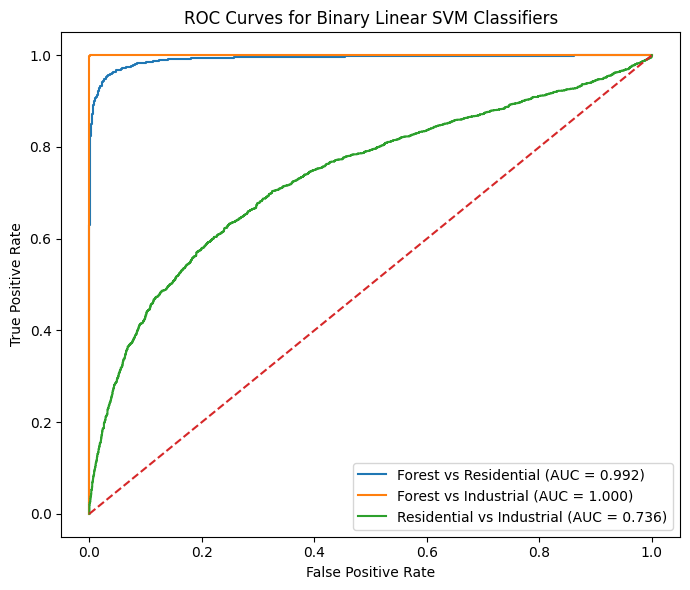

In [16]:
# ROC curves
plt.figure(figsize=(7, 6))

for result in [svm_fr, svm_fi, svm_ri]:
    plt.plot(
        result["fpr"],
        result["tpr"],
        label=f"{result['class_a_name']} vs {result['class_b_name']} (AUC = {result['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Binary Linear SVM Classifiers")
plt.legend()
plt.tight_layout()
plt.show()

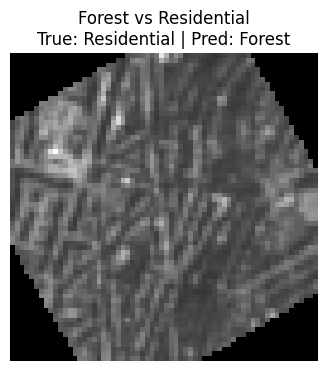

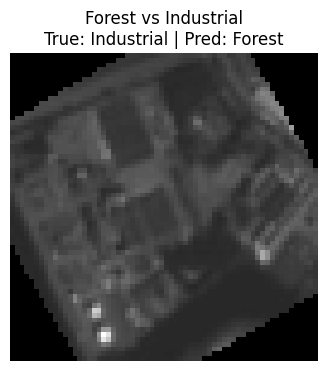

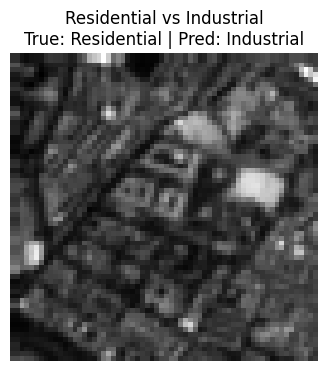

In [17]:
# missed classification
def plot_misclassified_example(result):
    mis = result["mis_example"]

    if mis is None:
        print(f"No misclassified example found for {result['class_a_name']} vs {result['class_b_name']}.")
        return

    img = mis["image_flat"].reshape(64, 64)

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")
    plt.title(
        f"{result['class_a_name']} vs {result['class_b_name']}\n"
        f"True: {mis['true_label_name']} | Pred: {mis['pred_label_name']}"
    )
    plt.axis("off")
    plt.show()

for result in [svm_fr, svm_fi, svm_ri]:
    plot_misclassified_example(result)

In [18]:
# save the result
import joblib
from pathlib import Path

SAVE_DIR = Path("data/saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(svm_fr["model"], SAVE_DIR / "svm_forest_vs_residential.joblib")
joblib.dump(svm_fi["model"], SAVE_DIR / "svm_forest_vs_industrial.joblib")
joblib.dump(svm_ri["model"], SAVE_DIR / "svm_residential_vs_industrial.joblib")

results_to_save = {
    "Forest_vs_Residential": {
        "accuracy": svm_fr["accuracy"],
        "auc": svm_fr["auc"],
        "fpr": svm_fr["fpr"],
        "tpr": svm_fr["tpr"],
        "mis_example": svm_fr["mis_example"],
    },
    "Forest_vs_Industrial": {
        "accuracy": svm_fi["accuracy"],
        "auc": svm_fi["auc"],
        "fpr": svm_fi["fpr"],
        "tpr": svm_fi["tpr"],
        "mis_example": svm_fi["mis_example"],
    },
    "Residential_vs_Industrial": {
        "accuracy": svm_ri["accuracy"],
        "auc": svm_ri["auc"],
        "fpr": svm_ri["fpr"],
        "tpr": svm_ri["tpr"],
        "mis_example": svm_ri["mis_example"],
    },
}

joblib.dump(results_to_save, SAVE_DIR / "binary_svm_results.joblib")

['data/saved_models/binary_svm_results.joblib']

In [ ]:
# To extract the results
'''
split_info = {
    "FOREST": FOREST,
    "RESIDENTIAL": RESIDENTIAL,
    "INDUSTRIAL": INDUSTRIAL,
}

joblib.dump(split_info, SAVE_DIR / "label_info.joblib")
'''

#### 2.2 Multiclass, Majority-Vote SVM
Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.

In [19]:
def get_binary_votes_and_scores(model_dict, X, class_a, class_b):
    """
    For one binary SVM, return:
    - predicted class labels (class_a or class_b)
    - score contribution for class_a and class_b

    Output:
    pred_labels: (N,)
    score_a: (N,)
    score_b: (N,)
    """
    model = model_dict["model"]

    # prediction in 0/1 space
    pred01 = model.predict(X)
    pred_labels = np.where(pred01 == 0, class_a, class_b)

    # score
    if hasattr(model, "predict_proba"):
        prob_b = model.predict_proba(X)[:, 1]
        score_b = prob_b
        score_a = 1 - prob_b
    else:
        # if using decision_function instead of predict_proba
        d = model.decision_function(X)
        prob_b = 1 / (1 + np.exp(-d))   # sigmoid to map into (0,1)
        score_b = prob_b
        score_a = 1 - prob_b

    return pred_labels, score_a, score_b

In [20]:
def multiclass_majority_vote(X, svm_fr, svm_fi, svm_ri):
    """
    Combine 3 binary one-vs-one SVMs into a 3-class classifier
    using majority voting, with score-based tie breaking.

    Returns:
    y_pred_final: final predicted labels in original class ids
    vote_matrix: vote counts per class
    score_matrix: accumulated confidence scores per class
    """
    class_list = [FOREST, RESIDENTIAL, INDUSTRIAL]
    class_to_col = {FOREST: 0, RESIDENTIAL: 1, INDUSTRIAL: 2}

    n = X.shape[0]
    vote_matrix = np.zeros((n, 3), dtype=int)
    score_matrix = np.zeros((n, 3), dtype=float)

    # Forest vs Residential
    pred_fr, score_f_fr, score_r_fr = get_binary_votes_and_scores(svm_fr, X, FOREST, RESIDENTIAL)
    for i, pred in enumerate(pred_fr):
        vote_matrix[i, class_to_col[pred]] += 1
    score_matrix[:, class_to_col[FOREST]] += score_f_fr
    score_matrix[:, class_to_col[RESIDENTIAL]] += score_r_fr

    # Forest vs Industrial
    pred_fi, score_f_fi, score_i_fi = get_binary_votes_and_scores(svm_fi, X, FOREST, INDUSTRIAL)
    for i, pred in enumerate(pred_fi):
        vote_matrix[i, class_to_col[pred]] += 1
    score_matrix[:, class_to_col[FOREST]] += score_f_fi
    score_matrix[:, class_to_col[INDUSTRIAL]] += score_i_fi

    # Residential vs Industrial
    pred_ri, score_r_ri, score_i_ri = get_binary_votes_and_scores(svm_ri, X, RESIDENTIAL, INDUSTRIAL)
    for i, pred in enumerate(pred_ri):
        vote_matrix[i, class_to_col[pred]] += 1
    score_matrix[:, class_to_col[RESIDENTIAL]] += score_r_ri
    score_matrix[:, class_to_col[INDUSTRIAL]] += score_i_ri

    # majority vote with tie-breaking by score sum
    y_pred_final = []
    for i in range(n):
        max_vote = vote_matrix[i].max()
        candidates = np.where(vote_matrix[i] == max_vote)[0]

        if len(candidates) == 1:
            chosen_col = candidates[0]
        else:
            # tie break using highest accumulated score
            chosen_col = candidates[np.argmax(score_matrix[i, candidates])]

        y_pred_final.append(class_list[chosen_col])

    y_pred_final = np.array(y_pred_final)
    return y_pred_final, vote_matrix, score_matrix

In [22]:
y_pred_mv, vote_matrix, score_matrix = multiclass_majority_vote(
    X_test, svm_fr, svm_fi, svm_ri
)

acc_mv = accuracy_score(y_test, y_pred_mv)
print(f"Majority-vote multiclass SVM accuracy: {acc_mv:.4f}")

Majority-vote multiclass SVM accuracy: 0.7715


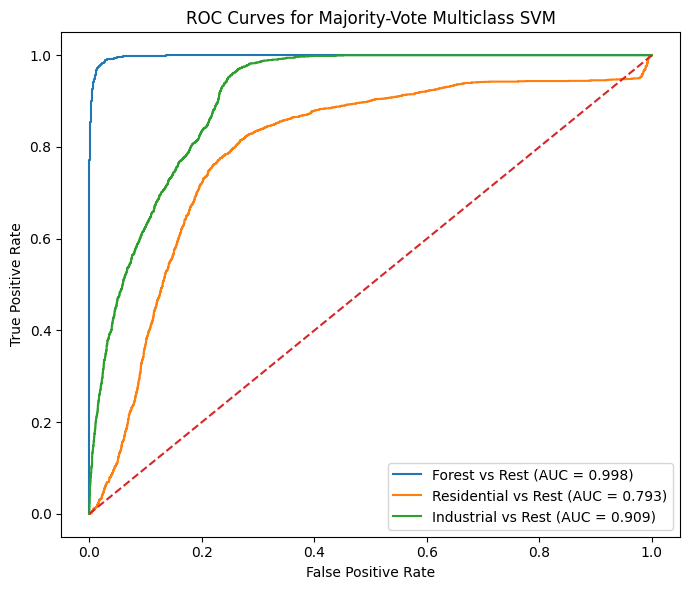

Forest AUC: 0.9982
Residential AUC: 0.7928
Industrial AUC: 0.9090


In [25]:
# binarize true labels in the same class order
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[FOREST, RESIDENTIAL, INDUSTRIAL])

fpr = {}
tpr = {}
roc_auc = {}

class_names_3 = [classes[FOREST], classes[RESIDENTIAL], classes[INDUSTRIAL]]

for i, cls_name in enumerate(class_names_3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], score_matrix[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7, 6))
for i, cls_name in enumerate(class_names_3):
    plt.plot(
        fpr[i], tpr[i],
        label=f"{cls_name} vs Rest (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Majority-Vote Multiclass SVM")
plt.legend()
plt.tight_layout()
plt.show()

for i, cls_name in enumerate(class_names_3):
    print(f"{cls_name} AUC: {roc_auc[i]:.4f}")

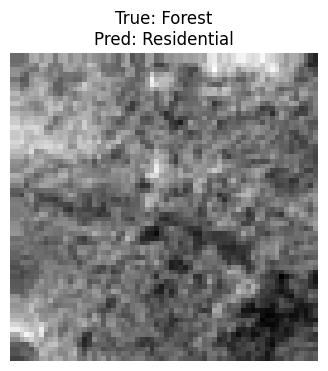

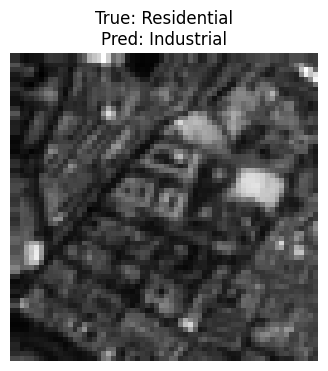

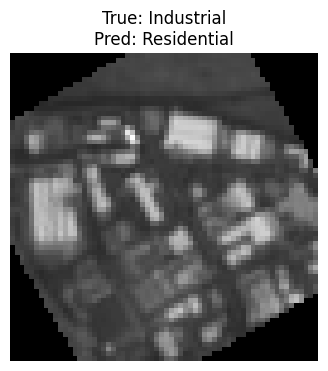

In [26]:
def plot_one_misclassified_per_true_class(X_test, y_test, y_pred_mv, classes):
    target_classes = [FOREST, RESIDENTIAL, INDUSTRIAL]

    for cls in target_classes:
        mis_idx = np.where((y_test == cls) & (y_pred_mv != y_test))[0]

        if len(mis_idx) == 0:
            print(f"No misclassified example found for true class = {classes[cls]}.")
            continue

        i = mis_idx[0]
        img = X_test[i].reshape(64, 64)

        plt.figure(figsize=(4, 4))
        plt.imshow(img, cmap="gray")
        plt.title(
            f"True: {classes[y_test[i]]}\nPred: {classes[y_pred_mv[i]]}"
        )
        plt.axis("off")
        plt.show()

plot_one_misclassified_per_true_class(X_test, y_test, y_pred_mv, classes)

#### 2.3 Multiclass Random Forest
Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.


In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.9253


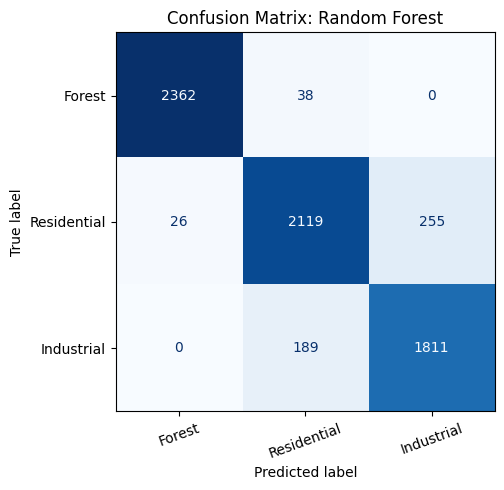

In [29]:
label_order = [FOREST, RESIDENTIAL, INDUSTRIAL]
label_names = [classes[FOREST], classes[RESIDENTIAL], classes[INDUSTRIAL]]

cm = confusion_matrix(y_test, y_pred_rf, labels=label_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix: Random Forest")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

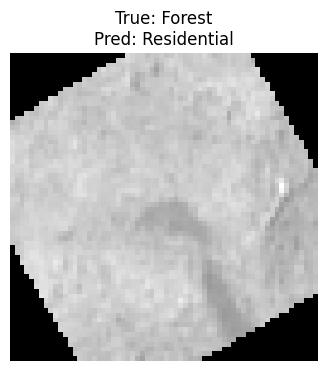

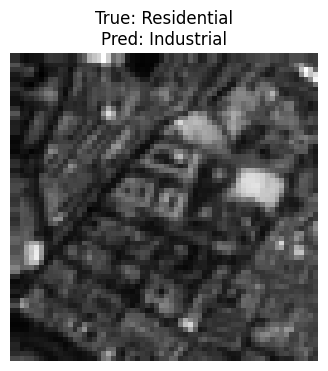

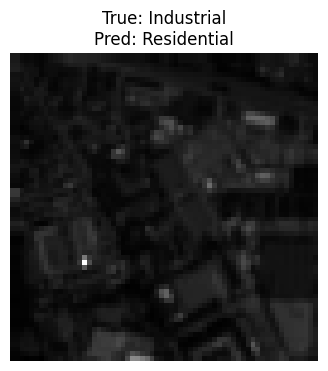

In [30]:
def plot_rf_misclassified_examples(X_test, y_test, y_pred, classes, class_list):
    for cls in class_list:
        mis_idx = np.where((y_test == cls) & (y_pred != y_test))[0]

        if len(mis_idx) == 0:
            print(f"No misclassified example found for true class = {classes[cls]}.")
            continue

        i = mis_idx[0]
        img = X_test[i].reshape(64, 64)

        plt.figure(figsize=(4, 4))
        plt.imshow(img, cmap="gray")
        plt.title(
            f"True: {classes[y_test[i]]}\nPred: {classes[y_pred[i]]}"
        )
        plt.axis("off")
        plt.show()

plot_rf_misclassified_examples(
    X_test, y_test, y_pred_rf,
    classes,
    [FOREST, RESIDENTIAL, INDUSTRIAL]
)

In [31]:
for cls in [FOREST, RESIDENTIAL, INDUSTRIAL]:
    mis_idx = np.where((y_test == cls) & (y_pred_rf != y_test))[0]

    if len(mis_idx) == 0:
        print(f"{classes[cls]}: no misclassified example found.")
    else:
        i = mis_idx[0]
        print(
            f"{classes[cls]} misclassified example -> "
            f"True: {classes[y_test[i]]}, Predicted: {classes[y_pred_rf[i]]}"
        )

Forest misclassified example -> True: Forest, Predicted: Residential
Residential misclassified example -> True: Residential, Predicted: Industrial
Industrial misclassified example -> True: Industrial, Predicted: Residential


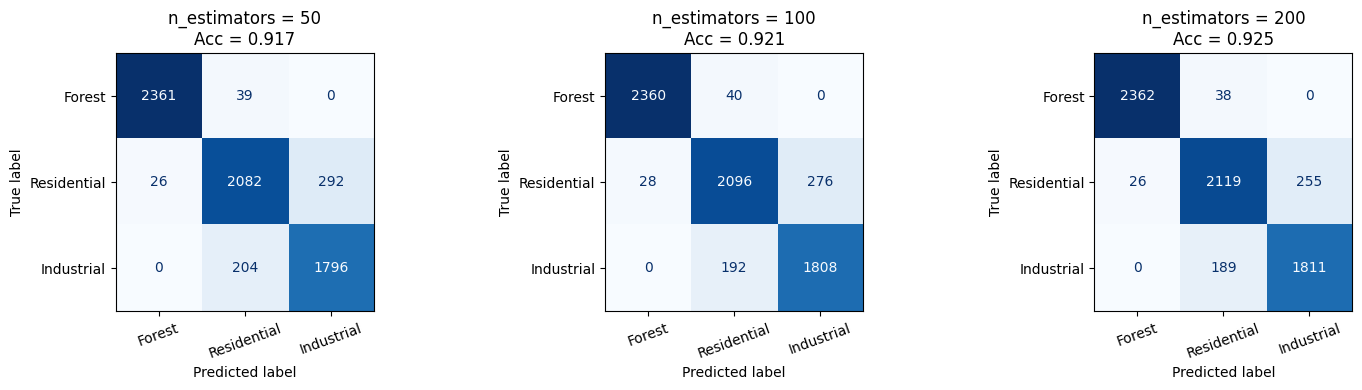

In [32]:
# compare different estimator and different result
n_list = [50, 100, 200]

label_order = [FOREST, RESIDENTIAL, INDUSTRIAL]
label_names = [classes[FOREST], classes[RESIDENTIAL], classes[INDUSTRIAL]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n in zip(axes, n_list):
    # train model
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # predict
    y_pred = rf.predict(X_test)

    # accuracy
    acc = accuracy_score(y_test, y_pred)

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=label_order)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names
    )

    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"n_estimators = {n}\nAcc = {acc:.3f}")
    ax.set_xticklabels(label_names, rotation=20)

plt.tight_layout()
plt.show()

### 3. Deep Learning

#### 3.1 Greyscale Images
For this section, use the same greyscale images that you used in the traditional machine learning section.


In [41]:
# load data
from tqdm.notebook import tqdm
import numpy as np

def ms_to_rgb(ms_img):
    # Sentinel-2 true color: B04, B03, B02
    return np.stack([ms_img[3], ms_img[2], ms_img[1]], axis=-1)

def rgb_to_gray(rgb_img):
    return (
        0.2989 * rgb_img[..., 0] +
        0.5870 * rgb_img[..., 1] +
        0.1140 * rgb_img[..., 2]
    ).astype(np.float32)

X_gray_full = []
y_full = []

for path, lbl in tqdm(all_samples, desc="Preparing full grayscale dataset"):
    ms = load_ms_array(path)      # should return (13, 64, 64)
    rgb = ms_to_rgb(ms)           # (64, 64, 3)
    gray = rgb_to_gray(rgb)       # (64, 64)

    X_gray_full.append(gray)
    y_full.append(lbl)

X_gray_full = np.stack(X_gray_full)              # (N, 64, 64)
y_full = np.array(y_full, dtype=np.int32)

print("X_gray_full shape:", X_gray_full.shape)
print("y_full shape:", y_full.shape)
print("Unique labels:", np.unique(y_full, return_counts=True))

Preparing full grayscale dataset:   0%|          | 0/54000 [00:00<?, ?it/s]

X_gray_full shape: (54000, 64, 64)
y_full shape: (54000,)
Unique labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([6000, 6000, 6000, 5000, 5000, 4000, 5000, 6000, 5000, 6000]))


In [46]:
# Flattern
X_gray_flat_full = X_gray_full.reshape(X_gray_full.shape[0], -1)
print("X_gray_flat_full shape:", X_gray_flat_full.shape)

X_gray_flat_full shape: (54000, 4096)


In [47]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train_gray_flat, X_test_gray_flat, y_train_full, y_test_full = train_test_split(
    X_gray_flat_full,
    y_full,
    test_size=0.4,
    random_state=42,
    stratify=y_full
)

print(X_train_gray_flat.shape, X_test_gray_flat.shape)
print(y_train_full.shape, y_test_full.shape)

(32400, 4096) (21600, 4096)
(32400,) (21600,)


In [48]:
# Normalized
train_max = X_train_gray_flat.max()

X_train_gray_flat_nn = X_train_gray_flat / (train_max + 1e-8)
X_test_gray_flat_nn = X_test_gray_flat / (train_max + 1e-8)

In [49]:
# one-hot encoding
from tensorflow.keras.utils import to_categorical

num_classes = 10
y_train_cat = to_categorical(y_train_full, num_classes=num_classes)
y_test_cat = to_categorical(y_test_full, num_classes=num_classes)

print(y_train_cat.shape, y_test_cat.shape)

(32400, 10) (21600, 10)


###### 3.1.1 Single-Layer Neural Network
Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e., input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)

In [50]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [51]:
single_layer_model = keras.Sequential([
    layers.Input(shape=(4096,)),
    layers.Dense(len(classes), activation="softmax")
])

single_layer_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
single_layer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [54]:
# epoch 15 + epoch 30
history_single = single_layer_model.fit(
    X_train_gray_flat_nn,
    y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    verbose=1
)

Epoch 1/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2810 - loss: 1.9872 - val_accuracy: 0.2614 - val_loss: 1.9948
Epoch 2/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2889 - loss: 1.9780 - val_accuracy: 0.2495 - val_loss: 1.9874
Epoch 3/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2845 - loss: 1.9722 - val_accuracy: 0.3000 - val_loss: 1.9810
Epoch 4/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2953 - loss: 1.9643 - val_accuracy: 0.3066 - val_loss: 1.9692
Epoch 5/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2965 - loss: 1.9554 - val_accuracy: 0.3091 - val_loss: 1.9664
Epoch 6/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2951 - loss: 1.9510 - val_accuracy: 0.3037 - val_loss: 1.9624
Epoch 7/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2985 - loss: 1.9441 - val_accuracy: 0.3002 - val_loss: 1.9604
Epoch 8/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3028 - loss: 1.9365 - val_accuracy: 

In [55]:
test_loss_single, test_acc_single = single_layer_model.evaluate(
    X_test_gray_flat_nn,
    y_test_cat,
    verbose=0
)

print(f"Single-Layer NN Test Accuracy: {test_acc_single:.4f}")
print(f"Single-Layer NN Test Loss: {test_loss_single:.4f}")

Single-Layer NN Test Accuracy: 0.3099
Single-Layer NN Test Loss: 1.8935


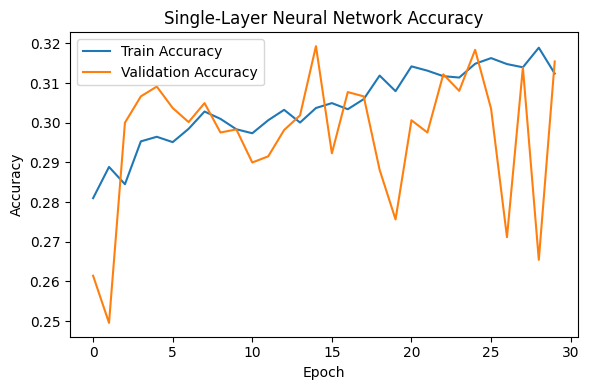

In [56]:
import matplotlib.pyplot as plt
# Accuracy visualization
plt.figure(figsize=(6, 4))
plt.plot(history_single.history["accuracy"], label="Train Accuracy")
plt.plot(history_single.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Single-Layer Neural Network Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

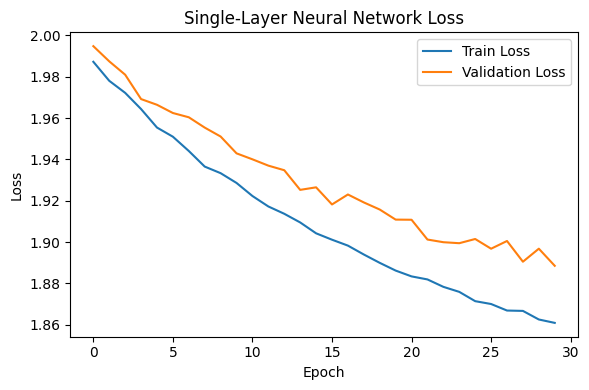

In [57]:
# Loss visualization
plt.figure(figsize=(6, 4))
plt.plot(history_single.history["loss"], label="Train Loss")
plt.plot(history_single.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Single-Layer Neural Network Loss")
plt.legend()
plt.tight_layout()
plt.show()

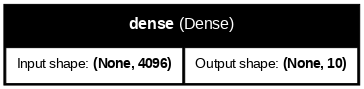

In [58]:
'''
from tensorflow.keras.utils import plot_model

plot_model(
    single_layer_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=70
)
'''

###### 3.1.2 Two-Layer Neural Network
Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?

In [59]:
# from tensorflow import keras
from tensorflow.keras import layers

two_layer_model = keras.Sequential([
    layers.Input(shape=(4096,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(classes), activation="softmax")
])

two_layer_model.summary()
from tensorflow import keras
from tensorflow.keras import layers

two_layer_model = keras.Sequential([
    layers.Input(shape=(4096,)),
    layers.Dense(128, activation="relu"), # hidden layer 128 nodes relu
    layers.Dense(len(classes), activation="softmax") # output layer 10 nodes
])

two_layer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# complie model
two_layer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [62]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_two = two_layer_model.fit(
    X_train_gray_flat_nn,
    y_train_cat,
    validation_split=0.2,
    epochs=20, # 30 + 20
    batch_size=128,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3819 - loss: 1.6344 - val_accuracy: 0.3739 - val_loss: 1.6599
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.3826 - loss: 1.6348 - val_accuracy: 0.3869 - val_loss: 1.6617
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3861 - loss: 1.6267 - val_accuracy: 0.3701 - val_loss: 1.6626
Epoch 4/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3846 - loss: 1.6253 - val_accuracy: 0.3833 - val_loss: 1.6461
Epoch 5/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3932 - loss: 1.6140 - val_accuracy: 0.3785 - val_loss: 1.6611
Epoch 6/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.3954 - loss: 1.6114 - val_accuracy: 0.3779 - val_loss: 1.6501
Epoch 7/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3941 - loss: 1.6092 - val_accuracy: 0.3892 - val_loss: 1.6522


In [63]:
test_loss_two, test_acc_two = two_layer_model.evaluate(
    X_test_gray_flat_nn,
    y_test_cat,
    verbose=0
)

print(f"Two-Layer NN Test Accuracy: {test_acc_two:.4f}")
print(f"Two-Layer NN Test Loss: {test_loss_two:.4f}")

Two-Layer NN Test Accuracy: 0.3752
Two-Layer NN Test Loss: 1.6487


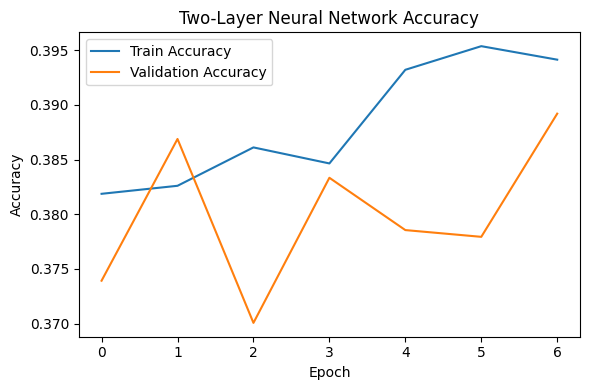

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history_two.history["accuracy"], label="Train Accuracy")
plt.plot(history_two.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Two-Layer Neural Network Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

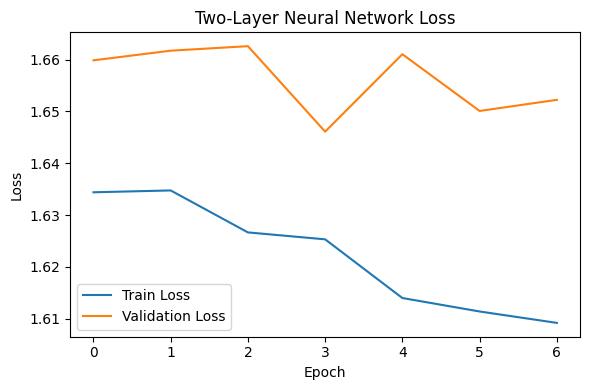

In [65]:
plt.figure(figsize=(6, 4))
plt.plot(history_two.history["loss"], label="Train Loss")
plt.plot(history_two.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Two-Layer Neural Network Loss")
plt.legend()
plt.tight_layout()
plt.show()

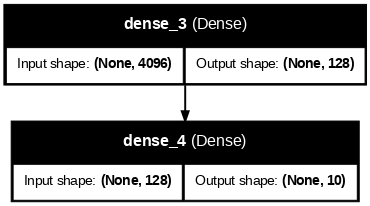

In [66]:
'''
from tensorflow.keras.utils import plot_model

plot_model(
    two_layer_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=70
)
'''

###### 3.1.3 Four-Layer Neural Network with Dropout
Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model's performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.



In [67]:
# define 4-layer model
from tensorflow import keras
from tensorflow.keras import layers

four_layer_model = keras.Sequential([
    layers.Input(shape=(4096,)),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(len(classes), activation="softmax")
])

four_layer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,090,634 (4.16 MB)

 Trainable params: 1,090,634 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
four_layer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [70]:
from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(
#     monitor="val_loss",
#     patience=4,
#     restore_best_weights=True
# )

history_four = four_layer_model.fit(
    X_train_gray_flat_nn,
    y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.3549 - loss: 1.7004 - val_accuracy: 0.2961 - val_loss: 1.9187
Epoch 2/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.3588 - loss: 1.6951 - val_accuracy: 0.3057 - val_loss: 1.8101
Epoch 3/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.3618 - loss: 1.6881 - val_accuracy: 0.2847 - val_loss: 1.9554
Epoch 4/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.3563 - loss: 1.6878 - val_accuracy: 0.3063 - val_loss: 1.8827
Epoch 5/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.3643 - loss: 1.6776 - val_accuracy: 0.3215 - val_loss: 1.7768
Epoch 6/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.3662 - loss: 1.6755 - val_accuracy: 0.3057 - val_loss: 1.8834
Epoch 7/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.3713 - loss: 1.6687 - val_accuracy: 0.3184 - val_loss: 1.8086
Epoch 8/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3681 - loss: 1.6659 - val_acc

In [71]:
test_loss_four, test_acc_four = four_layer_model.evaluate(
    X_test_gray_flat_nn,
    y_test_cat,
    verbose=0
)

print(f"Four-Layer NN with Dropout Test Accuracy: {test_acc_four:.4f}")
print(f"Four-Layer NN with Dropout Test Loss: {test_loss_four:.4f}")

Four-Layer NN with Dropout Test Accuracy: 0.3248
Four-Layer NN with Dropout Test Loss: 1.7782


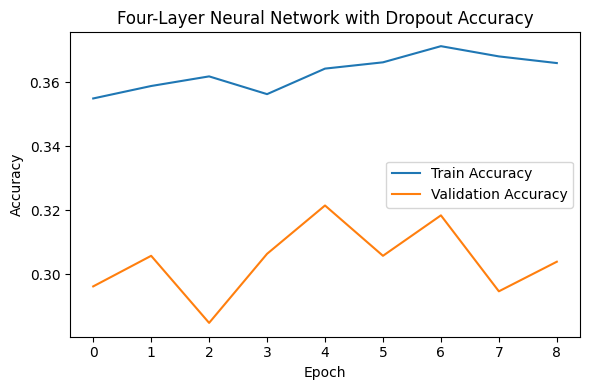

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history_four.history["accuracy"], label="Train Accuracy")
plt.plot(history_four.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Four-Layer Neural Network with Dropout Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

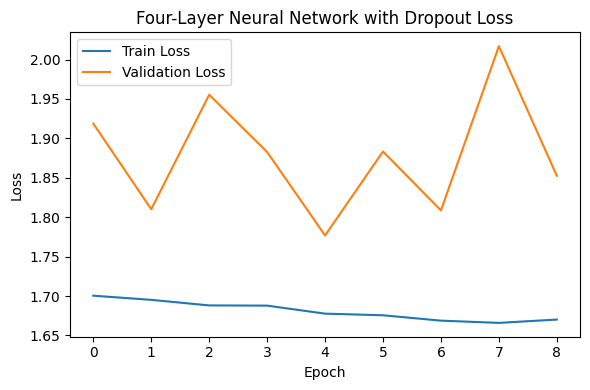

In [73]:
plt.figure(figsize=(6, 4))
plt.plot(history_four.history["loss"], label="Train Loss")
plt.plot(history_four.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Four-Layer Neural Network with Dropout Loss")
plt.legend()
plt.tight_layout()
plt.show()

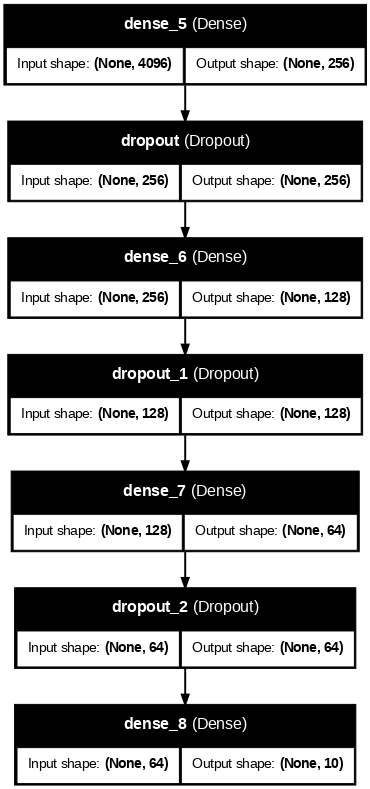

In [74]:
'''
from tensorflow.keras.utils import plot_model

plot_model(
    four_layer_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=70
)
'''

###### 3.1.4 Model Comparison and Ensemble
Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?

Implement an ensemble model that incorporates the predictions of models one through three. Calculate its classification accuracy on the test data. How does this compare to the accuracies of the three individual models? Describe the ensemble approach you implemented. Why might ensembling improve model accuracy compared to the individual models?



In [75]:
# compare model params
params_single = single_layer_model.count_params()
params_two = two_layer_model.count_params()
params_four = four_layer_model.count_params()

print(f"Single-layer params : {params_single:,}")
print(f"Two-layer params    : {params_two:,}")
print(f"Four-layer params   : {params_four:,}")

print("\nMargins:")
print(f"Two - Single  : {params_two - params_single:,}")
print(f"Four - Two    : {params_four - params_two:,}")
print(f"Four - Single : {params_four - params_single:,}")

Single-layer params : 40,970
Two-layer params    : 525,706
Four-layer params   : 1,090,634

Margins:
Two - Single  : 484,736
Four - Two    : 564,928
Four - Single : 1,049,664


In [76]:
# compare accuracy
print(f"Single-Layer Test Accuracy        : {test_acc_single:.4f}")
print(f"Two-Layer Test Accuracy           : {test_acc_two:.4f}")
print(f"Four-Layer NN + Dropout Accuracy  : {test_acc_four:.4f}")

Single-Layer Test Accuracy        : 0.3099
Two-Layer Test Accuracy           : 0.3752
Four-Layer NN + Dropout Accuracy  : 0.3248


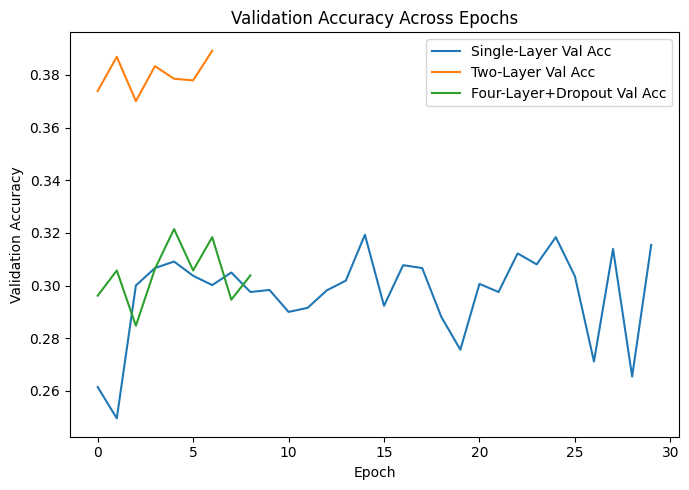

In [77]:
# compare epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(history_single.history["val_accuracy"], label="Single-Layer Val Acc")
plt.plot(history_two.history["val_accuracy"], label="Two-Layer Val Acc")
plt.plot(history_four.history["val_accuracy"], label="Four-Layer+Dropout Val Acc")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across Epochs")
plt.legend()
plt.tight_layout()
plt.show()

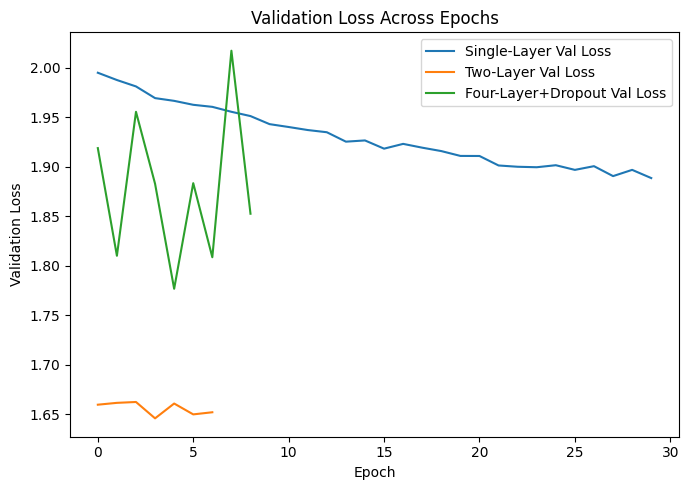

In [78]:
# compare log curves
plt.figure(figsize=(7, 5))

plt.plot(history_single.history["val_loss"], label="Single-Layer Val Loss")
plt.plot(history_two.history["val_loss"], label="Two-Layer Val Loss")
plt.plot(history_four.history["val_loss"], label="Four-Layer+Dropout Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Across Epochs")
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
# build essemble
# predicted class probabilities on test set
pred_single = single_layer_model.predict(X_test_gray_flat_nn, verbose=0)
pred_two = two_layer_model.predict(X_test_gray_flat_nn, verbose=0)
pred_four = four_layer_model.predict(X_test_gray_flat_nn, verbose=0)

print(pred_single.shape, pred_two.shape, pred_four.shape)  # should all be (N, 10)


# simple average ensemble
pred_ensemble = (pred_single + pred_two + pred_four) / 3.0

# final predicted class
y_pred_ensemble = pred_ensemble.argmax(axis=1)

# if y_test_full is still integer labels, use directly
from sklearn.metrics import accuracy_score

ensemble_acc = accuracy_score(y_test_full, y_pred_ensemble)
print(f"Ensemble Test Accuracy: {ensemble_acc:.4f}")



print(f"Single-Layer Accuracy       : {test_acc_single:.4f}")
print(f"Two-Layer Accuracy          : {test_acc_two:.4f}")
print(f"Four-Layer + Dropout Acc    : {test_acc_four:.4f}")
print(f"Ensemble Accuracy           : {ensemble_acc:.4f}")

(21600, 10) (21600, 10) (21600, 10)
Ensemble Test Accuracy: 0.3600
Single-Layer Accuracy       : 0.3099
Two-Layer Accuracy          : 0.3752
Four-Layer + Dropout Acc    : 0.3248
Ensemble Accuracy           : 0.3600
